# Indian Airlines Flight Price Analysis

### Data Analysis using Python

This project analyzes airline ticket pricing patterns using Python.
The analysis focuses on airline, travel class, number of stops,
days left before departure, flight duration, route, and other
factors associated with ticket prices.

# 1. Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the Dataset

In [2]:
df = pd.read_csv("/content/airlines_flights_data.csv")

In [3]:
# Display the first 5 rows

df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [4]:
# Remove the unnecessary index column from the dataset

df = df.drop(columns=["index"])

In [5]:
# Check the number of rows and columns

df.shape

(300153, 11)

In [6]:
# check data types and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


# 3. Data Quality Checks

In [7]:
# Check for missing values

df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [8]:
# Check for duplicate records

df.duplicated().sum()

np.int64(0)

# 4. Descriptive Statistics

In [9]:
# Check basic statistics of numerical columns

df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [10]:
# Check unique values in categorical columns

categorical_columns = [
    "airline",
    "source_city",
    "departure_time",
    "stops",
    "arrival_time",
    "destination_city",
    "class"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


airline:
['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']

source_city:
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']

departure_time:
['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']

stops:
['zero' 'one' 'two_or_more']

arrival_time:
['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']

destination_city:
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']

class:
['Economy' 'Business']


In [11]:
# Count flights by airline

df["airline"].value_counts()

,count
airline,
Vistara,127859
Air_India,80892
Indigo,43120
GO_FIRST,23173
AirAsia,16098
SpiceJet,9011


In [12]:
# Count flights by travel class

df["class"].value_counts()

,count
class,
Economy,206666
Business,93487


# 5. Exploratory Data Analysis

In [13]:
# Calculate average ticket price by airline

avg_price_airline = df.groupby("airline")["price"].mean().sort_values(ascending=False)

avg_price_airline

,price
airline,
Vistara,30396.536302
Air_India,23507.019112
SpiceJet,6179.278881
GO_FIRST,5652.007595
Indigo,5324.216303
AirAsia,4091.072742


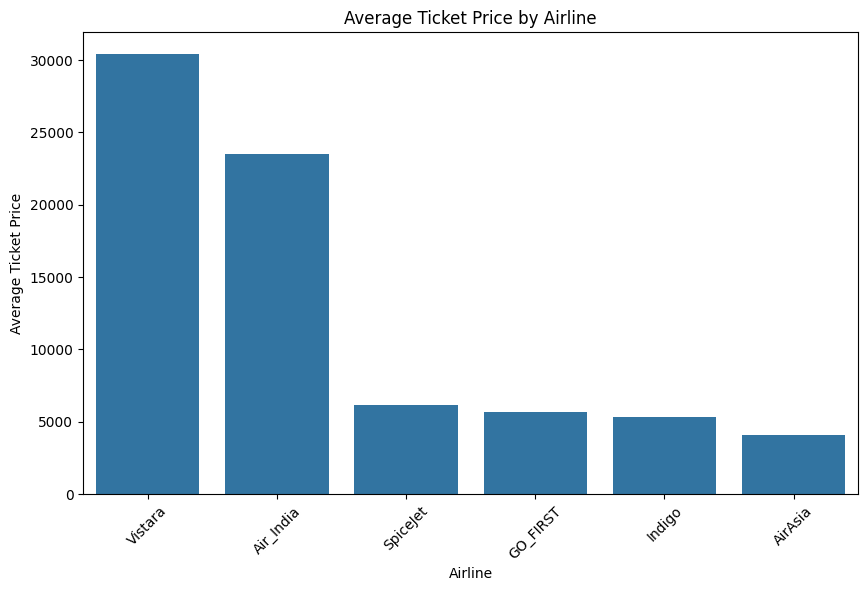

In [14]:
# Visualize average ticket price by airline

plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_price_airline.index,
    y=avg_price_airline.values
)

plt.title("Average Ticket Price by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Ticket Price")
plt.xticks(rotation=45)

plt.show()

In [15]:
# Calculate average ticket price by travel class

avg_price_class = df.groupby("class")["price"].mean().sort_values(ascending=False)

avg_price_class

,price
class,
Business,52540.081124
Economy,6572.342383


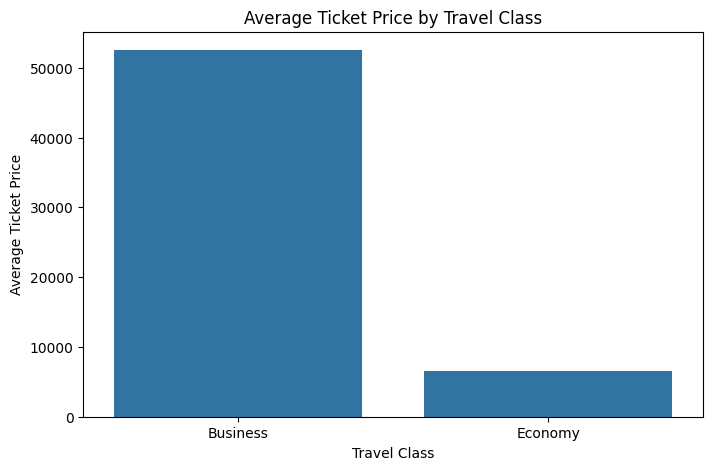

In [16]:
# Visualize average ticket price by travel class

plt.figure(figsize=(8, 5))

sns.barplot(
    x=avg_price_class.index,
    y=avg_price_class.values
)

plt.title("Average Ticket Price by Travel Class")
plt.xlabel("Travel Class")
plt.ylabel("Average Ticket Price")

plt.show()

In [17]:
# Calculate average ticket price by number of stops

avg_price_stops = df.groupby("stops")["price"].mean().sort_values(ascending=False)

avg_price_stops

,price
stops,
one,22900.992482
two_or_more,14113.450775
zero,9375.938535


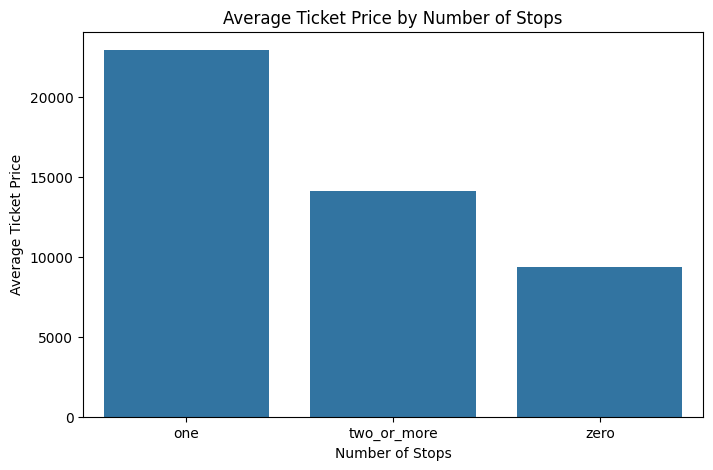

In [18]:
# Visualize average ticket price by number of stops

plt.figure(figsize=(8, 5))

sns.barplot(
    x=avg_price_stops.index,
    y=avg_price_stops.values
)

plt.title("Average Ticket Price by Number of Stops")
plt.xlabel("Number of Stops")
plt.ylabel("Average Ticket Price")

plt.show()

In [19]:
# Calculate average ticket price by days left before departure

avg_price_days = df.groupby("days_left")["price"].mean()

avg_price_days

,price
days_left,
1,21591.867151
2,30211.299801
3,28976.083569
4,25730.905653
5,26679.773368
6,24856.493902
7,25588.367351
8,24895.883995
9,25726.246072


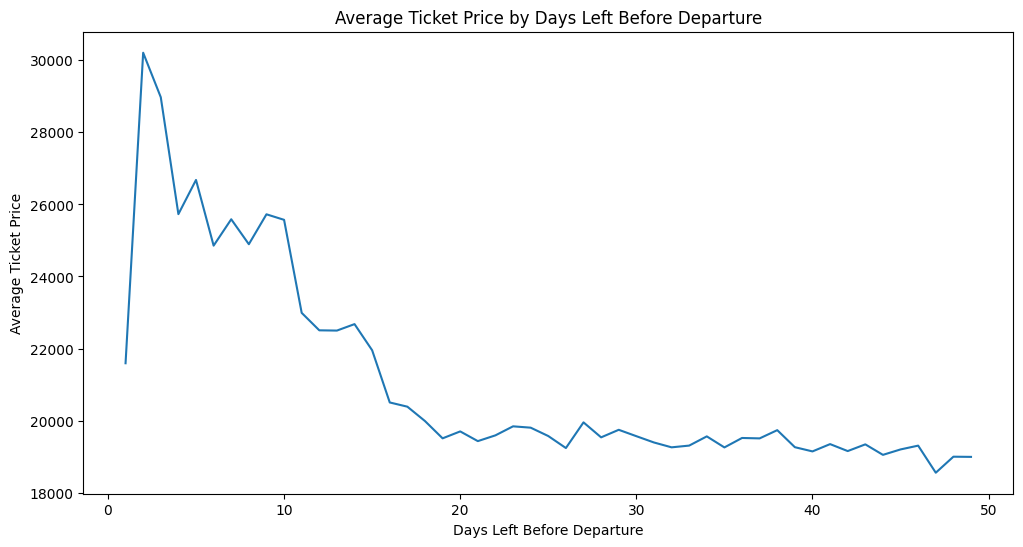

In [20]:
# Visualize average ticket price by days left before departure

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=avg_price_days.index,
    y=avg_price_days.values
)

plt.title("Average Ticket Price by Days Left Before Departure")
plt.xlabel("Days Left Before Departure")
plt.ylabel("Average Ticket Price")

plt.show()

In [21]:
# Calculate correlation between flight duration and ticket price

duration_price_corr = df["duration"].corr(df["price"])

duration_price_corr

np.float64(0.20422236784542702)

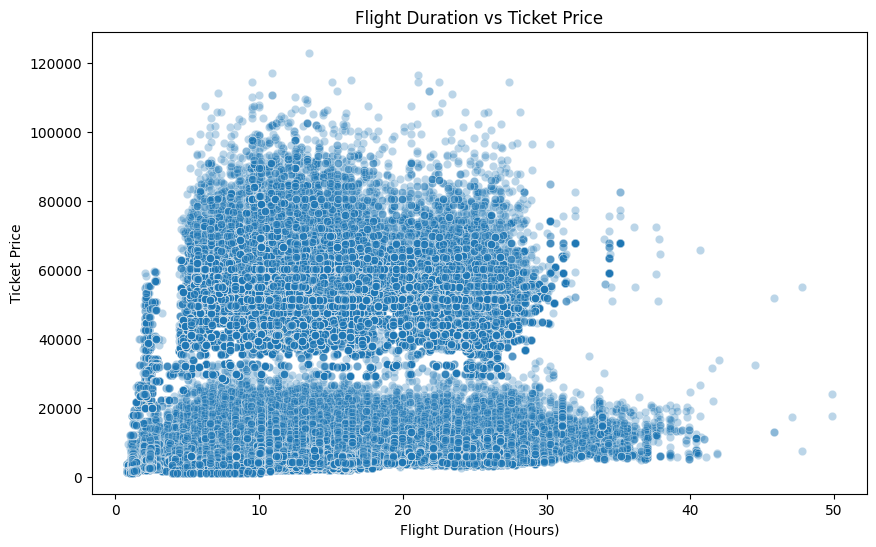

In [22]:
# Visualize the relationship between flight duration and ticket price

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="duration",
    y="price",
    alpha=0.3
)

plt.title("Flight Duration vs Ticket Price")
plt.xlabel("Flight Duration (Hours)")
plt.ylabel("Ticket Price")

plt.show()

In [23]:
# Create a route column using source and destination cities

df["route"] = df["source_city"] + " → " + df["destination_city"]

In [24]:
# Display sample routes

df[["source_city", "destination_city", "route"]].head()

,source_city,destination_city,route
0,Delhi,Mumbai,Delhi → Mumbai
1,Delhi,Mumbai,Delhi → Mumbai
2,Delhi,Mumbai,Delhi → Mumbai
3,Delhi,Mumbai,Delhi → Mumbai
4,Delhi,Mumbai,Delhi → Mumbai


In [25]:
# Calculate average ticket price by route

avg_price_route = (
    df.groupby("route")["price"]
      .mean()
      .sort_values(ascending=False)
)

avg_price_route.head(10)

,price
route,
Chennai → Bangalore,25081.850454
Kolkata → Chennai,23660.361040
Bangalore → Kolkata,23500.061229
Bangalore → Chennai,23321.850078
Mumbai → Bangalore,23147.873807
Bangalore → Mumbai,23128.618672
Mumbai → Chennai,22781.899112
Chennai → Mumbai,22765.849647
Kolkata → Bangalore,22744.808428


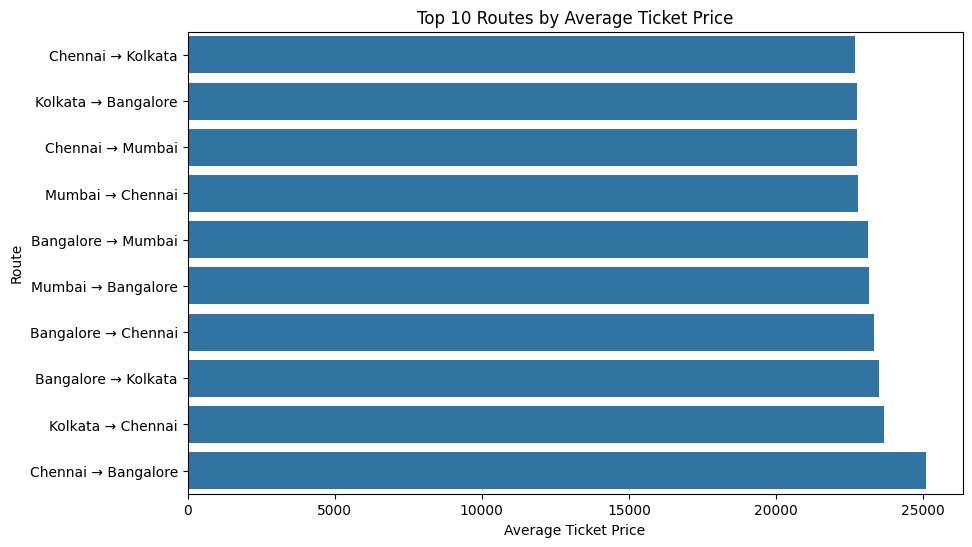

In [26]:
# Visualize the top 10 routes by average ticket price

top_10_routes = avg_price_route.head(10).sort_values()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_routes.values,
    y=top_10_routes.index
)

plt.title("Top 10 Routes by Average Ticket Price")
plt.xlabel("Average Ticket Price")
plt.ylabel("Route")

plt.show()

In [27]:
# Calculate the number of flights operated by each airline

flight_count_airline = df["airline"].value_counts()

flight_count_airline

,count
airline,
Vistara,127859
Air_India,80892
Indigo,43120
GO_FIRST,23173
AirAsia,16098
SpiceJet,9011


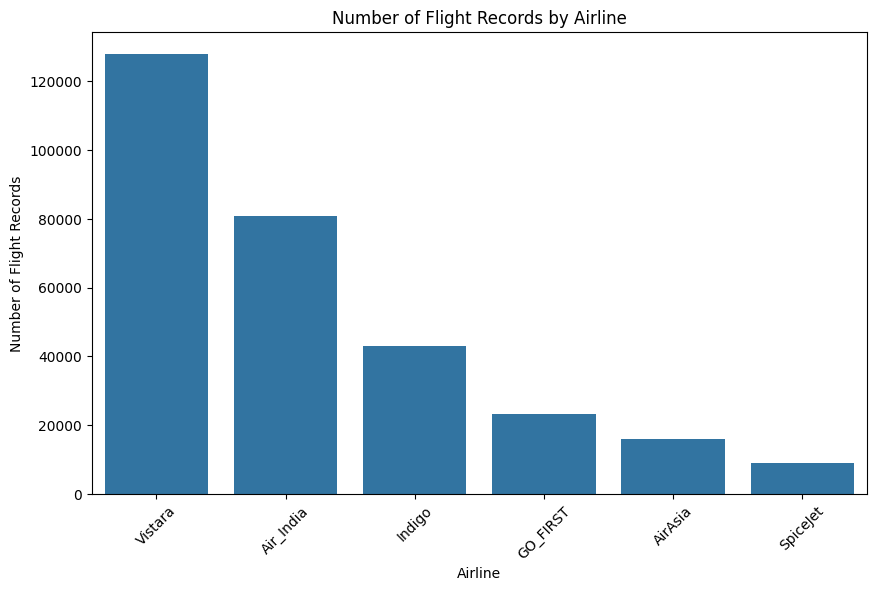

In [28]:
# Visualize the number of flights by airline

plt.figure(figsize=(10, 6))

sns.barplot(
    x=flight_count_airline.index,
    y=flight_count_airline.values
)

plt.title("Number of Flight Records by Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Flight Records")
plt.xticks(rotation=45)

plt.show()

In [29]:
# Calculate average ticket price by departure time

avg_price_departure = (
    df.groupby("departure_time")["price"]
      .mean()
      .sort_values(ascending=False)
)

avg_price_departure

,price
departure_time,
Night,23062.146808
Morning,21630.760254
Evening,21232.361894
Early_Morning,20370.676718
Afternoon,18179.203331
Late_Night,9295.299387


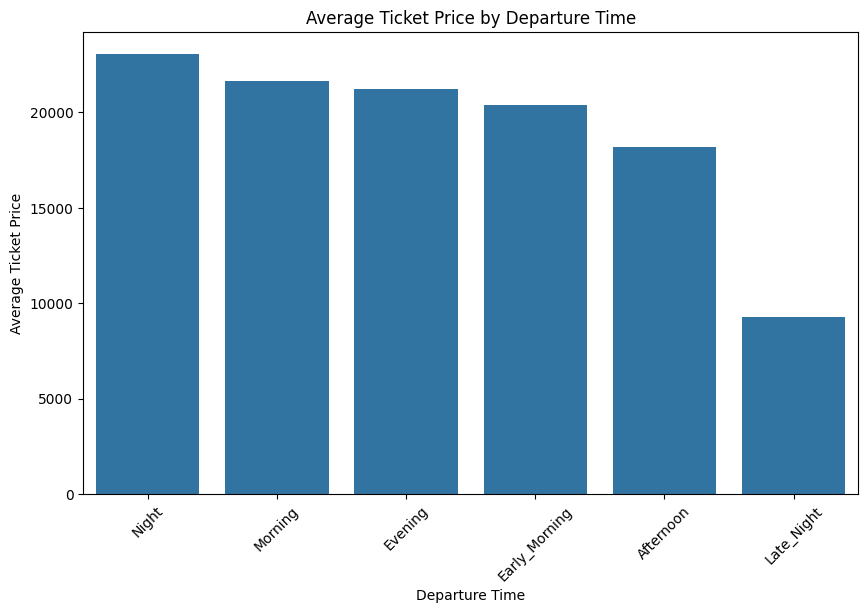

In [30]:
# Visualize average ticket price by departure time

plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_price_departure.index,
    y=avg_price_departure.values
)

plt.title("Average Ticket Price by Departure Time")
plt.xlabel("Departure Time")
plt.ylabel("Average Ticket Price")
plt.xticks(rotation=45)

plt.show()

In [31]:
# Calculate average ticket price by arrival time

avg_price_arrival = (
    df.groupby("arrival_time")["price"]
      .mean()
      .sort_values(ascending=False)
)

avg_price_arrival

,price
arrival_time,
Evening,23044.371615
Morning,22231.076098
Night,21586.758341
Afternoon,18494.598993
Early_Morning,14993.139521
Late_Night,11284.906078


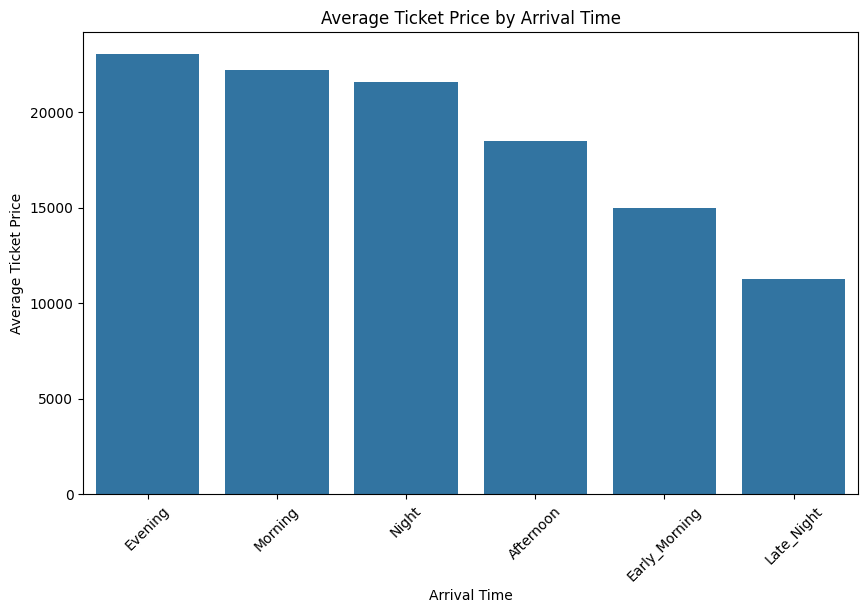

In [32]:
# Visualize average ticket price by arrival time

plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_price_arrival.index,
    y=avg_price_arrival.values
)

plt.title("Average Ticket Price by Arrival Time")
plt.xlabel("Arrival Time")
plt.ylabel("Average Ticket Price")
plt.xticks(rotation=45)

plt.show()

In [33]:
# Count Economy and Business flights for each airline

airline_class_count = pd.crosstab(
    df["airline"],
    df["class"]
)

airline_class_count

class,Business,Economy
airline,,
AirAsia,0,16098
Air_India,32898,47994
GO_FIRST,0,23173
Indigo,0,43120
SpiceJet,0,9011
Vistara,60589,67270


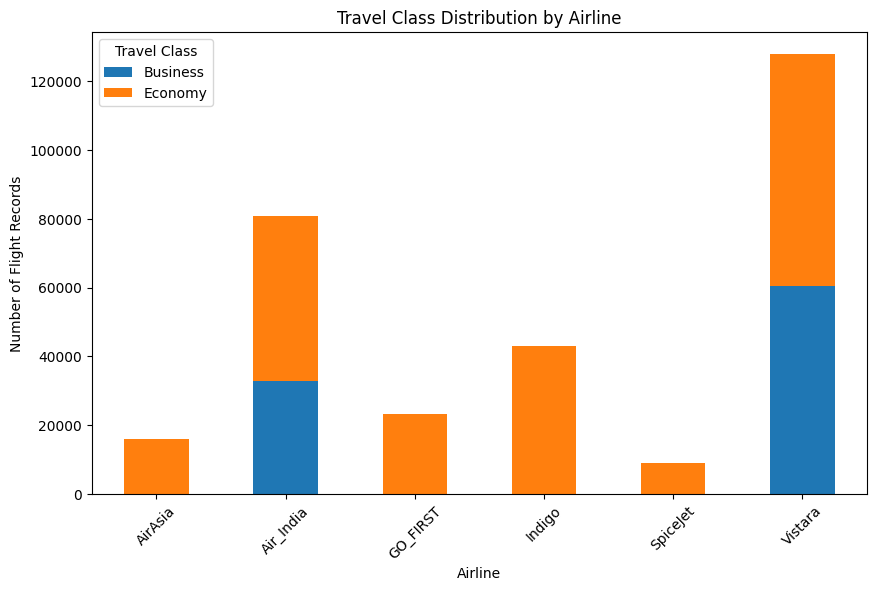

In [34]:
# Visualize travel class distribution by airline

airline_class_count.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Travel Class Distribution by Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Flight Records")
plt.xticks(rotation=45)

plt.legend(title="Travel Class")

plt.show()

In [35]:
# Calculate average ticket price by source city

avg_price_source = (
    df.groupby("source_city")["price"]
      .mean()
      .sort_values(ascending=False)
)

avg_price_source

,price
source_city,
Chennai,21995.339871
Kolkata,21746.235679
Mumbai,21483.818839
Bangalore,21469.460575
Hyderabad,20155.623879
Delhi,18951.326639


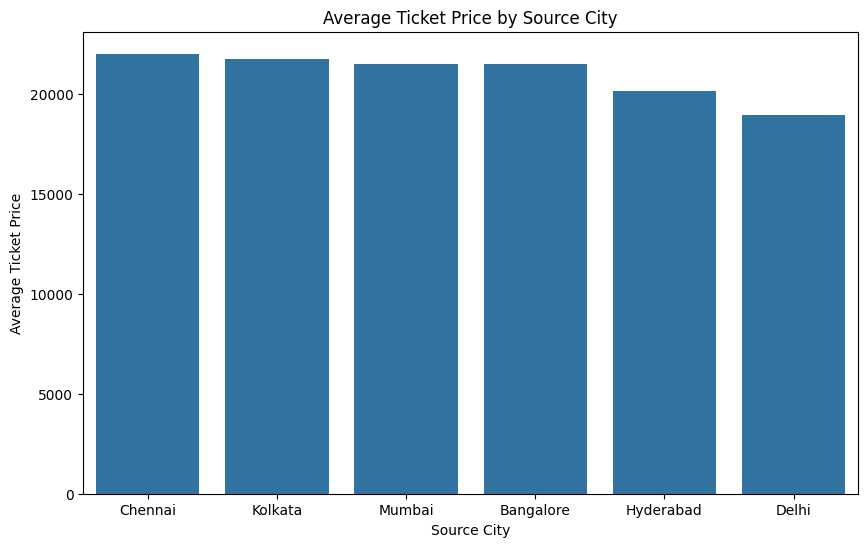

In [36]:
# Visualize average ticket price by source city

plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_price_source.index,
    y=avg_price_source.values
)

plt.title("Average Ticket Price by Source City")
plt.xlabel("Source City")
plt.ylabel("Average Ticket Price")

plt.show()

In [37]:
# Calculate average ticket price by destination city

avg_price_destination = (
    df.groupby("destination_city")["price"]
      .mean()
      .sort_values(ascending=False)
)

avg_price_destination

,price
destination_city,
Kolkata,21959.557556
Chennai,21953.323969
Bangalore,21593.955784
Mumbai,21372.529469
Hyderabad,20427.661284
Delhi,18436.767870


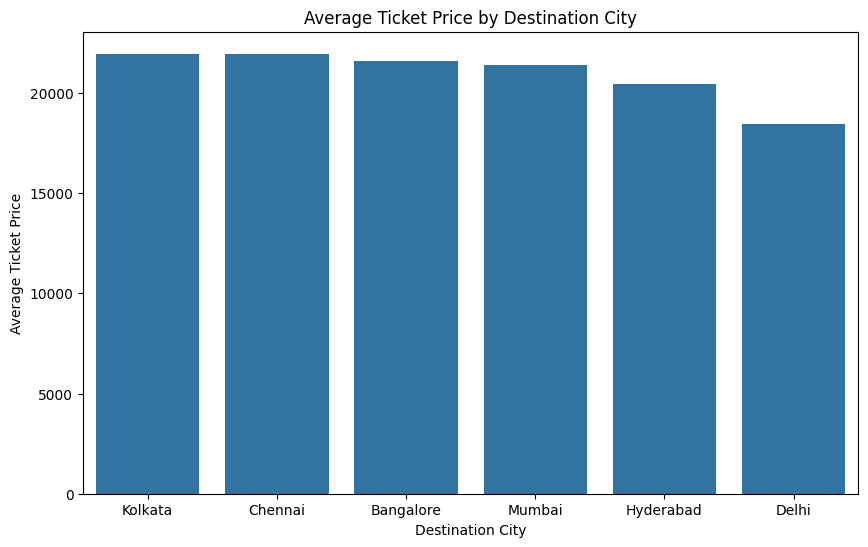

In [38]:
# Visualize average ticket price by destination city

plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_price_destination.index,
    y=avg_price_destination.values
)

plt.title("Average Ticket Price by Destination City")
plt.xlabel("Destination City")
plt.ylabel("Average Ticket Price")

plt.show()

In [39]:
# Calculate average ticket price by airline and travel class

airline_class_price = (
    df.groupby(["airline", "class"])["price"]
      .mean()
      .unstack()
)

airline_class_price

class,Business,Economy
airline,,
AirAsia,NaN,4091.072742
Air_India,47131.039212,7313.682169
GO_FIRST,NaN,5652.007595
Indigo,NaN,5324.216303
SpiceJet,NaN,6179.278881
Vistara,55477.027777,7806.943645


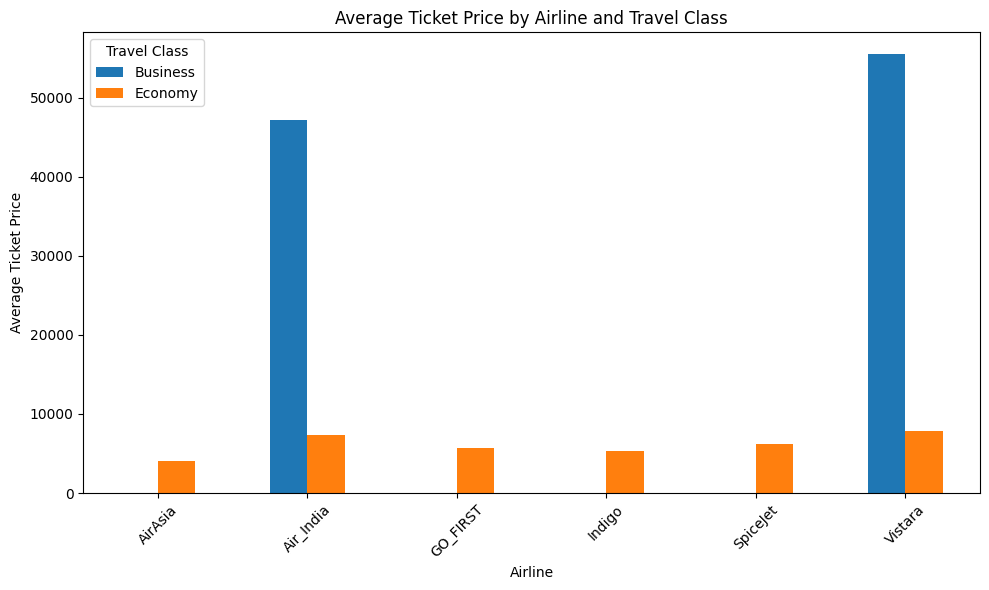

In [40]:
# Visualize average ticket price by airline and travel class

airline_class_price.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Ticket Price by Airline and Travel Class")
plt.xlabel("Airline")
plt.ylabel("Average Ticket Price")
plt.xticks(rotation=45)

plt.legend(title="Travel Class")

plt.tight_layout()
plt.show()

In [41]:
# Calculate average flight duration by travel class

class_duration = (
    df.groupby("class")["duration"]
      .mean()
)

class_duration

,duration
class,
Business,13.704274
Economy,11.550060


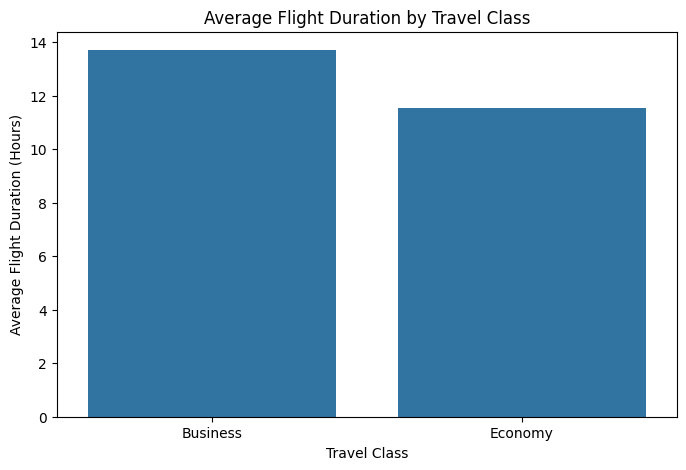

In [42]:
# Visualize average flight duration by travel class

plt.figure(figsize=(8, 5))

sns.barplot(
    x=class_duration.index,
    y=class_duration.values
)

plt.title("Average Flight Duration by Travel Class")
plt.xlabel("Travel Class")
plt.ylabel("Average Flight Duration (Hours)")

plt.show()

# 6. Key Findings and Conclusion

## Key Findings

- Vistara has the highest average ticket price among the airlines analyzed.
- Business-class tickets have a substantially higher average price than Economy-class tickets.
- Average ticket prices differ across the number of stops, with one-stop flights having the highest average price in this dataset.
- Average ticket prices generally tend to be higher when fewer days are left before departure, although the pattern is not perfectly consistent.
- Flight duration shows a weak positive correlation with ticket price (r ≈ 0.20).
- Average ticket prices vary across different routes, with Chennai → Bangalore having the highest average price among the top routes analyzed.
- Airlines differ in the number of flight records represented in the dataset and in their average ticket prices.
- Average ticket prices vary across airlines and travel classes.

## Conclusion

This analysis explores airline ticket pricing patterns using Python.
It examines differences in ticket prices based on airline, travel class,
number of stops, days left before departure, flight duration, route,
departure time, arrival time, source city, and destination city.

The project demonstrates data loading, data quality checks,
descriptive statistics, data aggregation, feature engineering,
exploratory data analysis, and data visualization to derive
meaningful insights from the dataset.